In [1]:
import os
import sys

project_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..')) 

sys.path.append(os.path.join(project_root, 'Scripts'))

from model_utils.data import *
from data_utils.visualization import *

from data_utils.colors_config import *
from data_utils.processing import *
from model_utils.preprocessing import *

import umap
#from model_utils.data import *
#from model_utils.trainer import *

ModuleNotFoundError: No module named 'umap'

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans

In [5]:
import pandas as pd
import numpy as np
pd.set_option('display.max_columns', None)

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.io as pio
pio.renderers.default = "png"
import pandas as pd
import plotly.express as px

from adjustText import adjust_text

import config
from data_utils import *

In [6]:
data = pd.read_parquet(config.TIDY_DATA_PATH)

In [7]:
data.season.unique()

array([2223, 2324, 2425, 2526])

In [8]:
data.shape

(100409, 41)

In [9]:
data.tail()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,season,gw,code
100404,George Brierley,MID,Burnley,-1.0,0,0,0,0,0.0,784,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2026-02-22T16:30:00,0,0,0,0,0,27,0,0.0,0,4.0,1.0,0.0,0,0,19,19,4.5,False,0,2526,27,704232
100405,George Brierley,MID,Burnley,-0.5,0,0,0,0,0.0,784,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2026-03-01T16:30:00,0,0,0,0,0,28,0,0.0,0,1.0,2.0,0.0,0,-1,19,20,4.5,True,0,2526,28,704232
100406,George Brierley,MID,Burnley,-0.5,0,0,0,0,0.0,784,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2026-03-04T19:30:00,0,0,0,0,0,29,0,0.0,0,1.0,0.0,0.0,0,-5,33,38,4.5,False,0,2526,29,704232
100407,George Brierley,MID,Burnley,-0.5,0,0,0,0,0.0,784,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2026-03-15T14:00:00,0,0,0,0,0,30,0,0.0,0,0.0,2.0,0.0,0,-2,7,9,4.5,True,0,2526,30,704232
100408,George Brierley,MID,Burnley,-0.5,0,0,0,0,0.0,784,0.0,0.0,0.0,0.0,0,0,0.0,0.0,2026-04-11T14:00:00,0,0,0,0,0,32,0,0.0,0,2.0,1.0,0.0,0,-4,14,18,4.5,True,0,2526,32,704232


In [10]:
def numpy_dtypes(df:pd.DataFrame)->pd.DataFrame:
    df = df.copy()
    num_cols = df.select_dtypes(include=np.number).columns
    df[num_cols] = df[num_cols].astype(np.float32)

    return df

In [11]:
data.rename(columns={
    "expected_goals_conceded" : "xg_conceded",
    "expected_goals" : "xg",
    "expected_goal_involvements" : "xg_involvements",
    "team_expected_points" : "team_xp",
    "opp_expected_points" : "opp_xp",
    "expected_assists" : "xa"
}, inplace=True)

In [12]:
def exp_per_90(df: pd.DataFrame, x_cols: list[str]) -> pd.DataFrame:
    df = df.copy()

    df = df.reset_index(drop=True)

    minutes = pd.to_numeric(df['minutes'], errors='coerce').replace(0, np.nan)

    for col in x_cols:
        new_col = f"{col}_per_90"

        num_col = pd.to_numeric(df[col], errors='coerce')

        result = num_col / (minutes / 90.0)

        result = result.replace([np.inf, -np.inf], np.nan).fillna(0)
        df[new_col] = result.astype(float)

    return df

In [13]:
data = numpy_dtypes(data)
data = exp_per_90(data, [c for c in data.columns if "x" in c and c !="ict_index" and c != "xP"])
data = data[data.name.isin(list(data.groupby(['name', 'season']).filter(lambda x: x['minutes'].sum() > 90).name.unique()))]

In [14]:
data.shape

(73499, 45)

In [15]:
data = data.loc[data.position != "AM", :]

In [16]:
data = sort_data(data)
data.head()

,name,position,team,xP,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,goals_conceded,goals_scored,ict_index,influence,kickoff_time,minutes,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,was_home,yellow_cards,season,gw,code,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90
0,Cristiano Ronaldo dos Santos Aveiro,FWD,Man Utd,4.1,0.0,0.0,3.0,0.0,11.500000,326.0,0.0,0.0,0.0,0.0,0.0,0.0,3.6,4.6,2022-08-07T13:00:00Z,37.0,0.0,0.0,0.0,0.0,1.0,0.0,352984.0,0.0,2.0,1.0,20.0,1.0,0.0,0.0,0.0,10.5,True,0.0,2223.0,1.0,14937.0,0.0,0.0,0.0,0.0
1,Cristiano Ronaldo dos Santos Aveiro,FWD,Man Utd,2.0,0.0,0.0,2.0,0.0,35.599998,326.0,0.0,0.0,0.0,0.0,4.0,0.0,6.9,7.8,2022-08-13T16:30:00Z,90.0,0.0,0.0,0.0,0.0,2.0,0.0,414347.0,0.0,0.0,4.0,26.0,2.0,-43311.0,32101.0,75412.0,10.5,False,0.0,2223.0,2.0,14937.0,0.0,0.0,0.0,0.0
2,Cristiano Ronaldo dos Santos Aveiro,FWD,Man Utd,0.8,0.0,0.0,1.0,0.0,0.000000,326.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.0,2022-08-22T19:00:00Z,4.0,0.0,0.0,0.0,0.0,3.0,0.0,345362.0,0.0,1.0,2.0,3.0,1.0,-96904.0,16665.0,113569.0,10.4,True,0.0,2223.0,3.0,14937.0,0.0,0.0,0.0,0.0
3,Cristiano Ronaldo dos Santos Aveiro,FWD,Man Utd,1.7,0.0,0.0,-1.0,0.0,0.700000,326.0,0.0,0.0,0.0,0.0,0.0,0.0,0.8,0.0,2022-08-27T11:30:00Z,22.0,0.0,0.0,0.0,0.0,4.0,0.0,339885.0,0.0,1.0,0.0,8.0,1.0,-36719.0,23950.0,60669.0,10.4,False,0.0,2223.0,4.0,14937.0,0.0,0.0,0.0,0.0
4,Cristiano Ronaldo dos Santos Aveiro,FWD,Man Utd,1.7,0.0,0.0,0.0,0.0,10.600000,326.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,2022-09-01T19:00:00Z,22.0,0.0,0.0,0.0,0.0,5.0,0.0,287761.0,0.0,1.0,0.0,12.0,1.0,-61838.0,4182.0,66020.0,10.3,False,0.0,2223.0,5.0,14937.0,0.0,0.0,0.0,0.0


In [17]:
data.describe()

,xP,assists,bonus,bps,clean_sheets,creativity,element,xa,xg_involvements,xg,xg_conceded,goals_conceded,goals_scored,ict_index,influence,minutes,own_goals,penalties_missed,penalties_saved,red_cards,round,saves,selected,starts,team_a_score,team_h_score,threat,total_points,transfers_balance,transfers_in,transfers_out,value,yellow_cards,season,gw,code,xa_per_90,xg_involvements_per_90,xg_per_90,xg_conceded_per_90
count,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,7.349900e+04,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,7.349900e+04,7.349900e+04,7.349900e+04,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000,73499.000000
mean,1.490103,0.156601,0.395475,21.844038,0.383529,17.673010,332.554688,0.104236,0.274402,0.171268,1.846164,1.857916,0.167404,6.094065,26.972061,120.900436,0.006925,0.003415,0.001850,0.007592,19.638525,0.345950,2.468913e+05,1.311310,1.380794,1.616512,16.363760,1.535028,1.721170e+03,1.925989e+04,1.753862e+04,5.072897,0.229051,2359.942871,19.638525,261687.140625,0.056012,0.147236,0.093046,0.984606
std,2.090587,0.638518,1.516953,60.754597,1.211996,58.685970,205.205719,0.390906,0.992722,0.700628,5.131464,5.037913,0.727453,17.345398,77.485100,325.466827,0.089556,0.070000,0.043292,0.086801,10.796261,3.820424,7.097444e+05,3.722565,1.212403,1.331597,55.192093,2.597278,8.641748e+04,7.188752e+04,6.428193e+04,1.133069,0.772716,105.046913,10.796261,161452.125000,0.435317,0.742547,0.558966,2.477460
min,-3.000000,0.000000,0.000000,-25.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,-5.000000,-2.741008e+06,0.000000e+00,0.000000e+00,3.600000,0.000000,2223.000000,1.000000,14937.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,161.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,10.000000,0.000000,2.514000e+03,0.000000,0.000000,1.000000,0.000000,0.000000,-1.882000e+03,6.800000e+01,2.090000e+02,4.400000,0.000000,2223.000000,10.000000,144485.000000,0.000000,0.000000,0.000000,0.000000
50%,0.700000,0.000000,0.000000,3.000000,0.000000,0.300000,312.000000,0.000000,0.000000,0.000000,0.080000,0.000000,0.000000,0.700000,2.000000,22.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,1.916400e+04,0.000000,1.000000,1.000000,0.000000,1.000000,-1.010000e+02,6.160000e+02,1.522000e+03,4.800000,0.000000,2324.000000,20.000000,212721.000000,0.000000,0.000000,0.000000,0.290000
75%,2.400000,0.000000,0.000000,15.000000,0.000000,11.800000,498.000000,0.030000,0.110000,0.040000,1.320000,1.000000,0.000000,4.000000,17.900000,90.000000,0.000000,0.000000,0.000000,0.000000,29.000000,0.000000,1.453275e+05,1.000000,2.000000,2.000000,8.000000,2.000000,1.240000e+02,6.628000e+03,1.012500e+04,5.400000,0.000000,2425.000000,29.000000,444034.500000,0.033725,0.115028,0.036432,1.420000
max,24.799999,19.000000,36.000000,845.000000,15.000000,1587.900024,860.000000,9.600000,19.980000,13.750000,71.260002,71.000000,14.000000,320.500000,1095.400024,3150.000000,2.000000,2.000000,2.000000,1.000000,38.000000,127.000000,9.582624e+06,35.000000,8.000000,9.000000,941.000000,26.000000,1.674116e+06,1.689375e+06,2.766073e+06,15.400000,10.000000,2526.000000,38.000000,699989.000000,50.399998,62.999996,54.000000,128.699997


In [18]:
data.shape

(73499, 45)

/tmp/ipykernel_8846/2440303749.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data.groupby("position")["name"].nunique(), palette="magma", legend=False)


Text(0, 0.5, 'Liczba graczy')

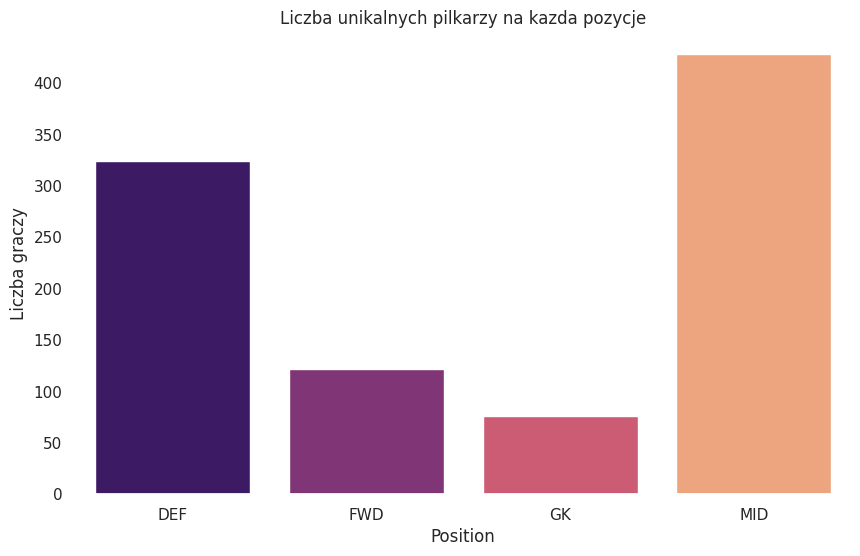

In [19]:
plt.figure(figsize=(10,6))
sns.barplot(data=data.groupby("position")["name"].nunique(), palette="magma", legend=False)
plt.title("Liczba unikalnych pilkarzy na kazda pozycje")
plt.xlabel("Position")
plt.ylabel("Liczba graczy")

In [20]:
[c for c in data.columns if "points" in c]

['total_points']

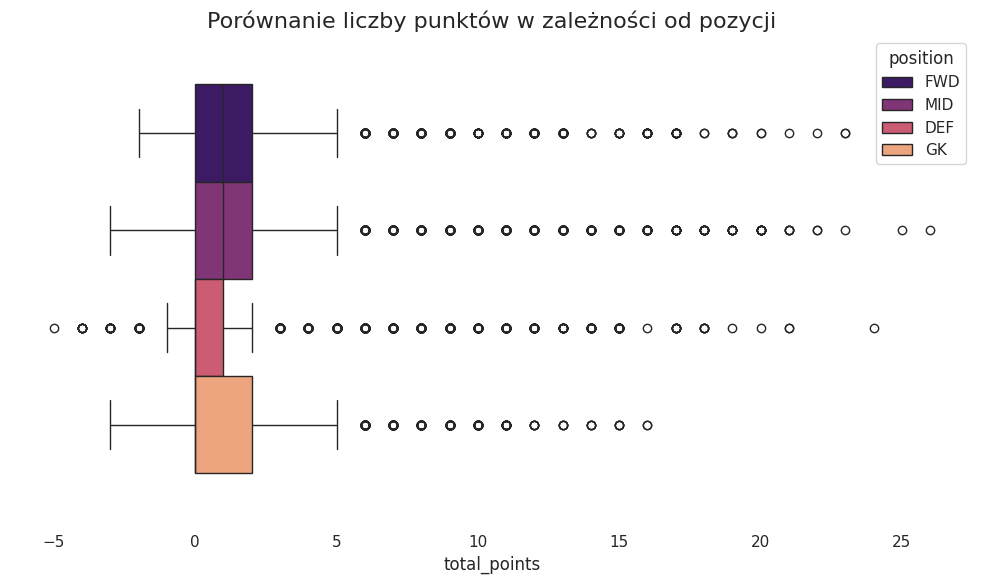

In [21]:
plt.figure(figsize=(10,  6))
sns.boxplot(data=data, x="total_points", hue="position", palette="magma")

plt.title("Porównanie liczby punktów w zależności od pozycji", fontsize=16)

plt.tight_layout()


/tmp/ipykernel_8846/2517760481.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(data.total_points,


Text(0.5, 1.0, 'Rozkład Total Points')

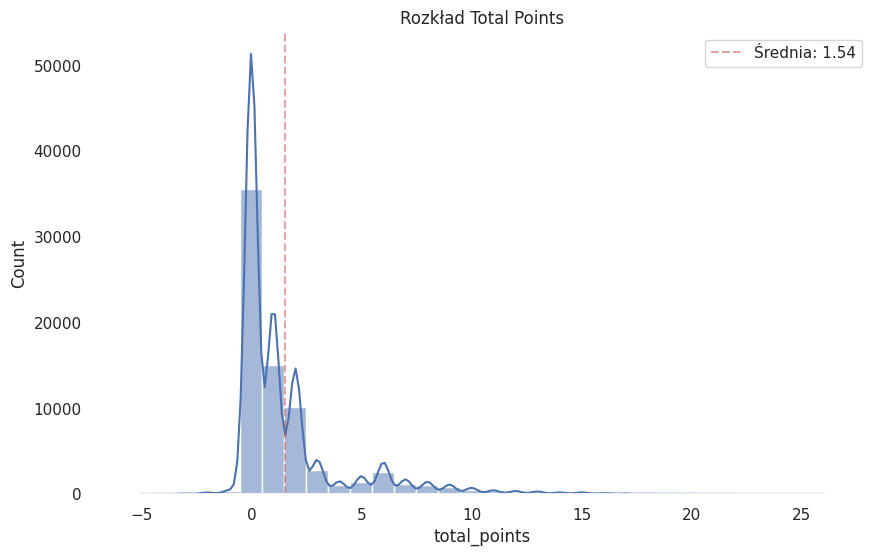

In [22]:
plt.figure(figsize=(10,6))

ax = sns.histplot(data.total_points,
             kde=True,
             palette="magma",
             discrete=True,
             bins=30)
ax.axvline(data.total_points.mean(), linestyle="--", color="r", alpha=0.5, label=f"Średnia: {data.total_points.mean():.2f}")
plt.legend(loc="upper right")
plt.title("Rozkład Total Points")

<Axes: >

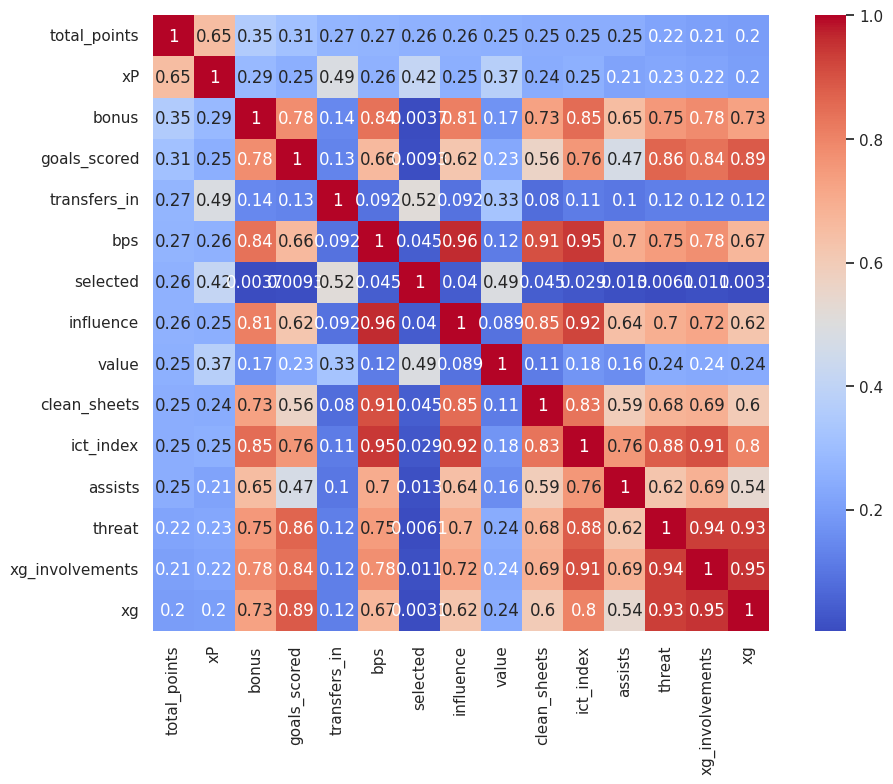

In [23]:
corr = data.select_dtypes(exclude=["object", "string"]).corr().apply(np.abs)
cols = corr["total_points"].sort_values(ascending=False).head(15).index

plt.figure(figsize=(12, 8))
sns.heatmap(corr.loc[cols, cols], annot=True, cmap="coolwarm", square=True)

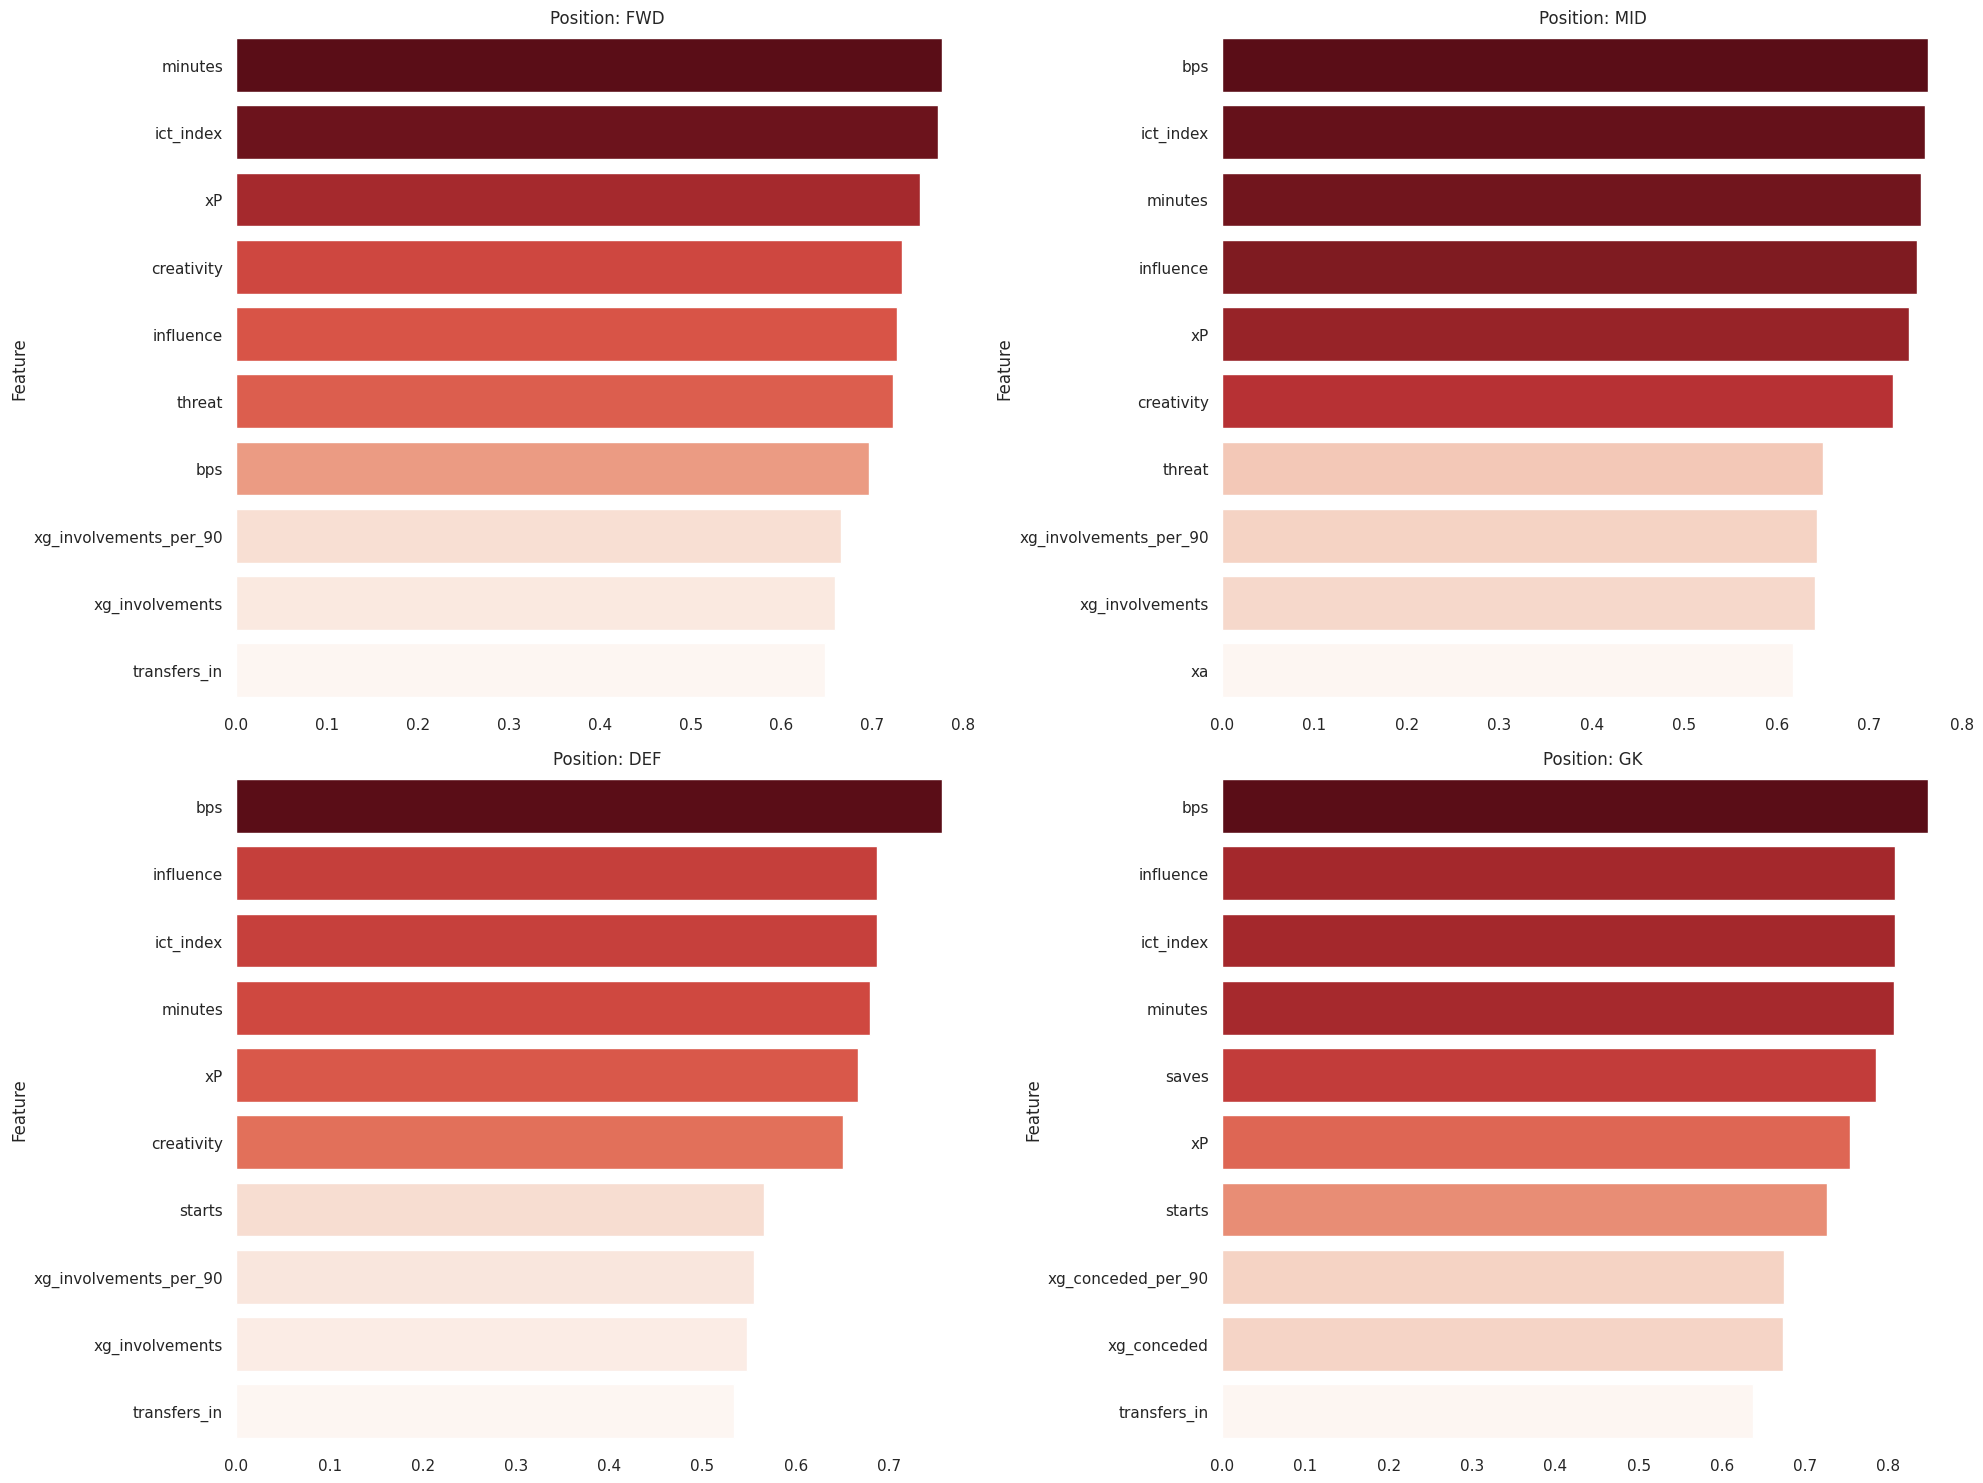

In [24]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(20, 15)) 
axes_flat = axes.flatten()

for idx, position in enumerate(data.position.unique()):
    subset = data[data.position == position].select_dtypes(exclude=["object", "string"])
    corr = subset.corr("spearman").apply(np.abs)
    
    plot_data = corr["total_points"].sort_values(ascending=False).head(11).drop(["total_points"])
    
    sns.barplot(
        x=plot_data.values,
        y=plot_data.index,
        ax=axes_flat[idx],
        hue=plot_data.values,
        palette="Reds",
        legend=False
    )
    
    axes_flat[idx].set_title(f"Position: {position}")
    axes_flat[idx].set_ylabel("Feature")

plt.tight_layout()

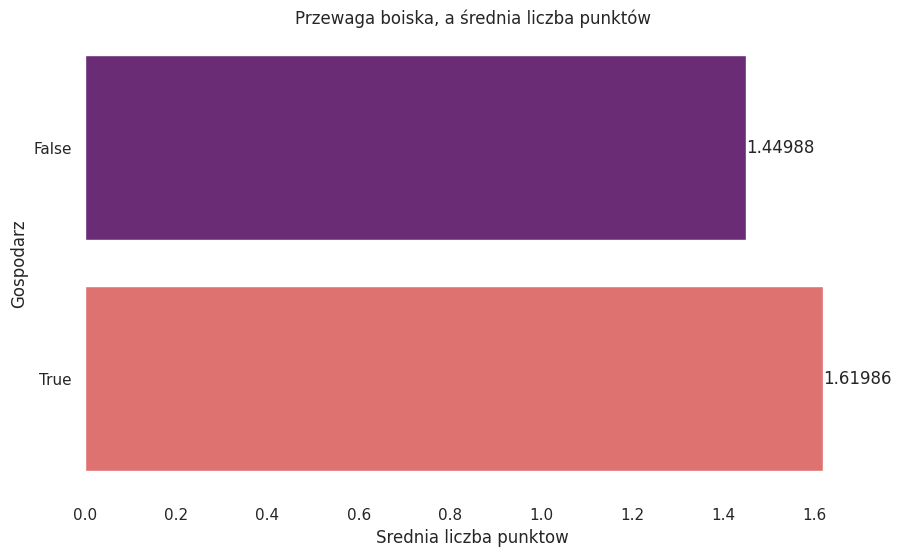

In [25]:
plt.figure(figsize=(10,6))
ax = sns.barplot(
    data=data,
    y="was_home",
    x="total_points",
    hue="was_home",
    estimator="mean",
    palette="magma",
    legend=False,
    errorbar=None,
    orient="h")

plt.xlabel("Srednia liczba punktow")
plt.ylabel("Gospodarz")

for container in ax.containers:
    ax.bar_label(container)
plt.title("Przewaga boiska, a średnia liczba punktów");

In [26]:
curr_gw = data[data.season==data.season.max()].gw.max()

In [27]:
fig = px.scatter(
    data[(data.season == data.season.max()) & (data.gw==curr_gw)],
    x="selected",
    y="total_points",
    color="position",
    facet_col="position",
    facet_col_wrap=2,
    hover_name="name", 
    hover_data={"selected": True, "total_points": True, "position": False},
    color_discrete_sequence=px.colors.sequential.Plasma,
    opacity=0.7,
    height=850,
    title="Punkty piłkarzy według pozycji i popularności"
)

fig.for_each_xaxis(lambda axis: axis.update(
    showticklabels=True, 
    tickformat=",d", 
    tickangle=0,
    showgrid=True,
    gridcolor='rgba(255, 255, 255, 0.1)',
    
))

fig.for_each_yaxis(lambda axis: axis.update(
    showticklabels=True, 
    tickformat=",d",
    showgrid=True,
    gridcolor='rgba(255, 255, 255, 0.1)',
    title_text="Suma punktów"
))

fig.update_layout(
    showlegend=False,
    template="plotly_dark",
    font=dict(
        family="Arial, sans-serif",
        size=12,
        color="#FFFFFF"
    ),    
    )


for annotation in fig["layout"]["annotations"]:
    annotation['font'] = dict(size=14, color="#FFFFFF", family="Arial Black")
    annotation['text'] = annotation['text'].split("=")[-1].upper()

fig.show(renderer="notebook")

In [28]:
data[(data.season==data.season.max()) & (data.gw==curr_gw)].loc[
    (data.selected < data.selected.quantile(.5)) &
    (data.total_points > data.total_points.quantile(.9)) &
    (data.minutes > 0),
["name", "position", "selected", "total_points", "xP", "gw", "minutes"]].sort_values(by=["position", "total_points"], ascending=False)

,name,position,selected,total_points,xP,gw,minutes
55481,Jaidon Anthony,MID,1.8,7.0,3.5,36.0,2543.0


In [29]:
team_x_stats = [c for c in data.columns if "x" in c and c!="ict_index" and ("team" in c or "opp" in c)]
player_x_stasts = [c for c in data.columns if "x" in c and c!="ict_index" and c not in team_x_stats and c !="xP"]

player_x_stasts

['xa',
 'xg_involvements',
 'xg',
 'xg_conceded',
 'xa_per_90',
 'xg_involvements_per_90',
 'xg_per_90',
 'xg_conceded_per_90']

In [30]:
data.position.unique()

<ArrowStringArray>
['FWD', 'MID', 'DEF', 'GK']
Length: 4, dtype: str

In [31]:
"""radar_plot_x_stats(df=data,
                   players=["Erling Haaland", "Antoine Semenyo", "Mohamed Salah", "Bruno Fernandes"],
                   stats=player_x_stasts)"""

'radar_plot_x_stats(df=data,\n                   players=["Erling Haaland", "Antoine Semenyo", "Mohamed Salah", "Bruno Fernandes"],\n                   stats=player_x_stasts)'

In [32]:
"""radar_plot_x_stats(df=data,
                   players=['Kenny Tete', "Marc Guéhi", "Lewis Hall",  'Trevoh Chalobah'],
                   stats=player_x_stasts)"""

'radar_plot_x_stats(df=data,\n                   players=[\'Kenny Tete\', "Marc Guéhi", "Lewis Hall",  \'Trevoh Chalobah\'],\n                   stats=player_x_stasts)'

In [33]:
pca_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA())
])

umap_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("umap", umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.001, random_state=77))
])

In [34]:
X = data.select_dtypes(exclude="object").drop(columns=["gw", "round", "code", "element", "season"])

In [35]:
pca1 = pca_pipe.fit_transform(X)


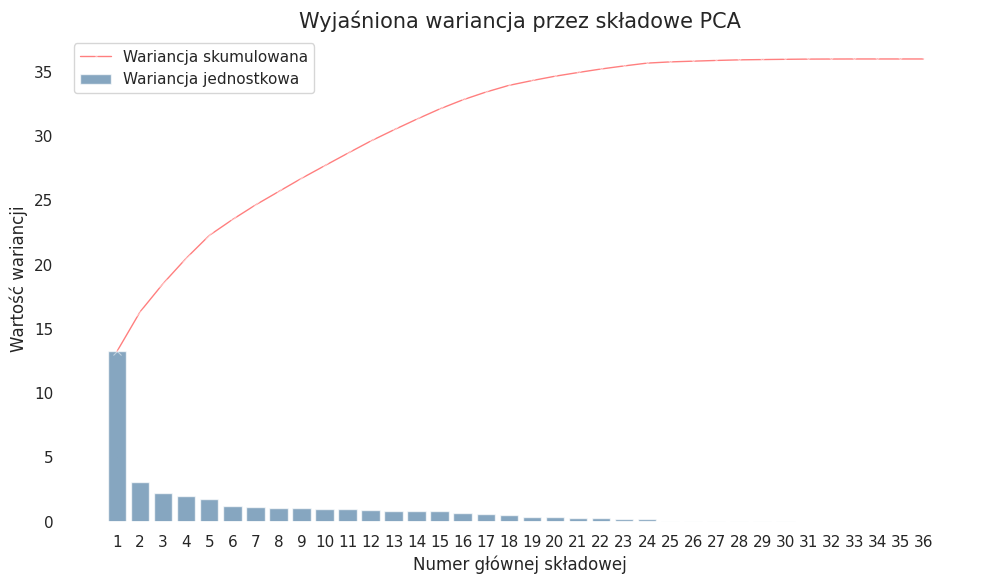

In [36]:
plt.figure(figsize=(10, 6))
ax = sns.barplot(x=list(range(1, len(pca_pipe.named_steps["pca"].explained_variance_) + 1)), y=pca_pipe.named_steps["pca"].explained_variance_, color="steelblue", alpha=0.7, label="Wariancja jednostkowa")

sns.lineplot(x=range(len(range(1, len(pca_pipe.named_steps["pca"].explained_variance_) + 1))), y=np.cumsum(pca_pipe.named_steps["pca"].explained_variance_), color="red", marker="x", linewidth=1, alpha=.5, label="Wariancja skumulowana")

plt.ticklabel_format(style='plain', axis='y', useOffset=False)

plt.title("Wyjaśniona wariancja przez składowe PCA", fontsize=15)
plt.xlabel("Numer głównej składowej", fontsize=12)
plt.ylabel("Wartość wariancji", fontsize=12)
plt.legend()

plt.tight_layout()

In [37]:
pca_pipe = Pipeline([
    ("scale", StandardScaler()),
    ("pca", PCA(2))
])

pca2 = pca_pipe.fit_transform(X)


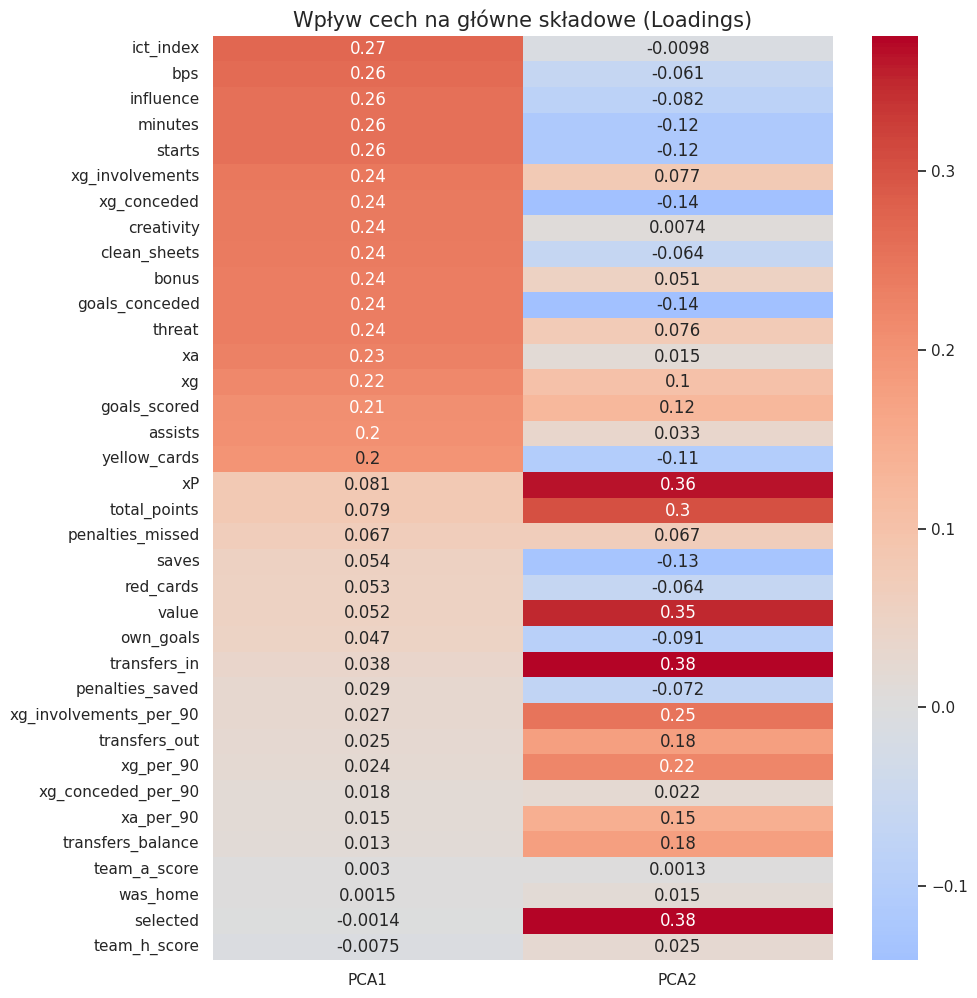

In [38]:
loadings = pd.DataFrame(
    pca_pipe.named_steps["pca"].components_[:2].T, 
    columns=['PCA1', 'PCA2'], 
    index=X.columns
)

plt.figure(figsize=(10, 12))
sns.heatmap(loadings.sort_values(by=["PCA1", "PCA2"], ascending=False), 
            annot=True, cmap='coolwarm', center=0)

plt.title("Wpływ cech na główne składowe (Loadings)", fontsize=15)
plt.show()

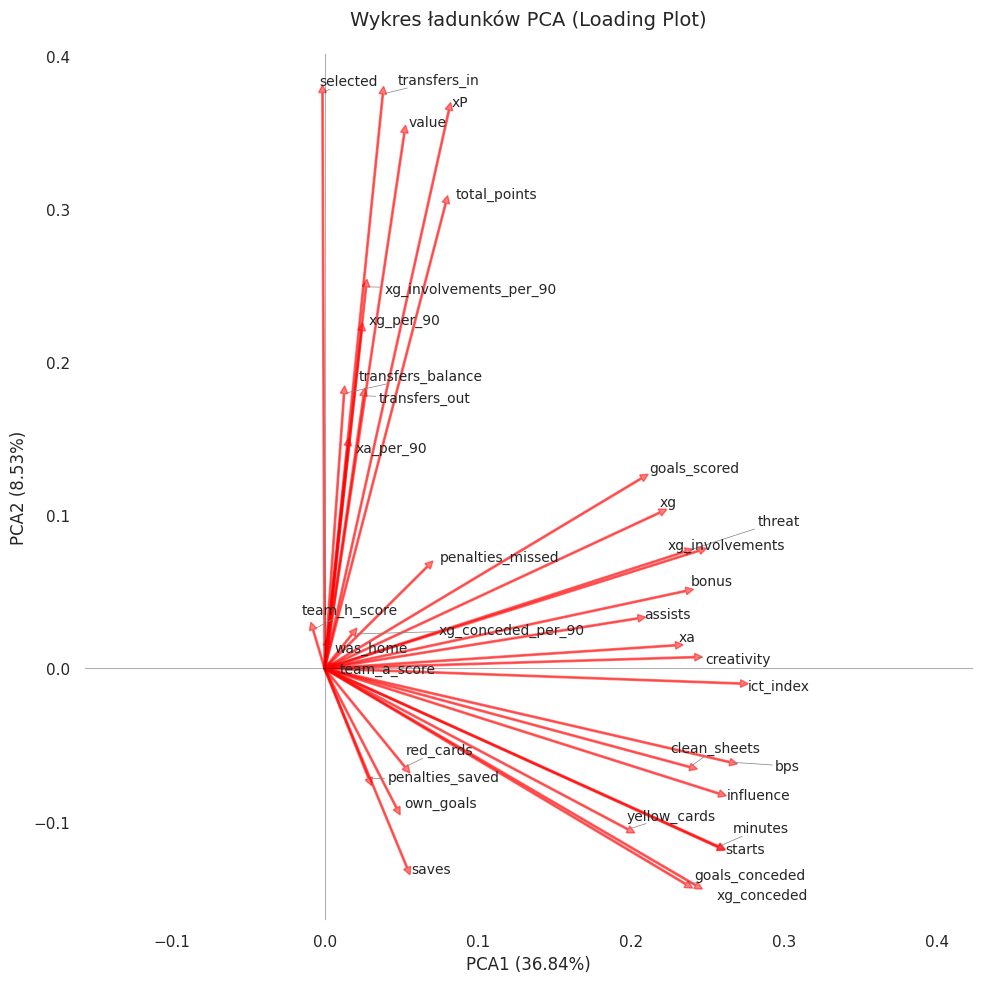

In [39]:
def plot_pca_loadings(loadings, pca_obj):
    plt.figure(figsize=(10, 10))
    
    texts = []
    for i, feature in enumerate(loadings.index):
        x = loadings.iloc[i, 0]
        y = loadings.iloc[i, 1]
        
        plt.arrow(0, 0, x, y, color='red', alpha=0.5, head_width=0.005, head_length=0.005)
        
        texts.append(plt.text(x, y, feature, fontsize=10, fontweight='medium'))

    circle = plt.Circle((0,0), 1, color='navy', fill=False, linestyle='--', alpha=0.2)
    plt.gca().add_artist(circle)

    plt.xlim(-1.1, 1.1)
    plt.ylim(-1.1, 1.1)
    plt.axis('equal')
    
    plt.axhline(0, color='black', linewidth=0.8, alpha=0.3)
    plt.axvline(0, color='black', linewidth=0.8, alpha=0.3)
    
    plt.xlabel(f'PCA1 ({pca_obj.explained_variance_ratio_[0]:.2%})')
    plt.ylabel(f'PCA2 ({pca_obj.explained_variance_ratio_[1]:.2%})')
    
    plt.title('Wykres ładunków PCA (Loading Plot)', fontsize=14, pad=20)
    plt.grid(alpha=0.2)

    adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

    plt.tight_layout()
    plt.show()

plot_pca_loadings(loadings, pca_pipe.named_steps["pca"])

In [40]:
embedding = umap_pipe.fit_transform(X)

/opt/python/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [41]:
df_umap = pd.concat([data, pd.DataFrame(embedding, columns=["umap_x", "umap_y"])], axis=1)

<Axes: xlabel='umap_x', ylabel='umap_y'>

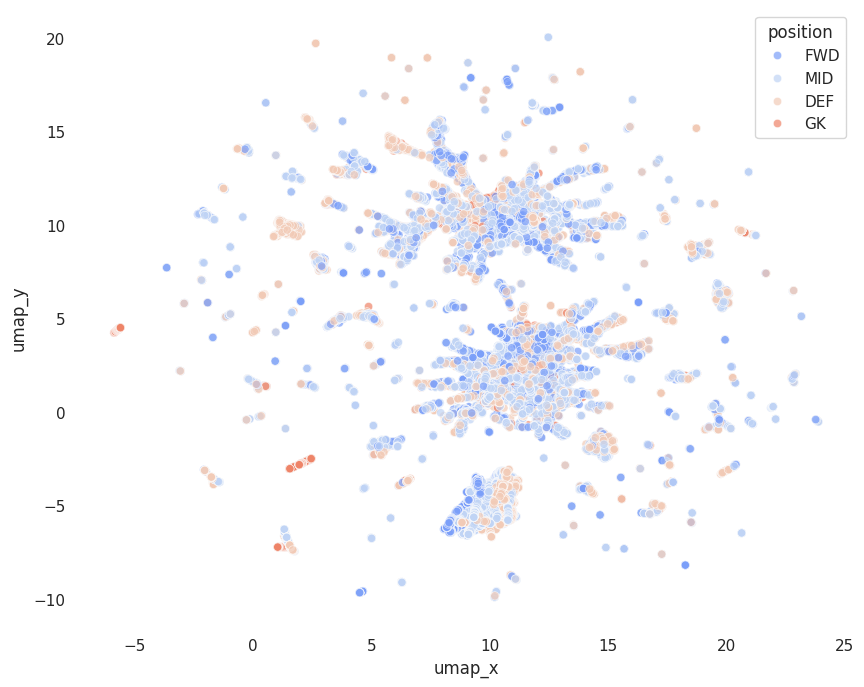

In [42]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df_umap, 
    x='umap_x', 
    y='umap_y', 
    hue='position',
    palette='coolwarm',
    alpha=0.7
)

In [43]:
km = KMeans(n_clusters=4)
positions = data.position.unique()

In [44]:
positions = data.position.unique()


MID:
K0: James Milner, James Milner, James Milner, James Milner, James Milner, James Milner, James Milner, James Milner
K1: Pascal Groß, Carlos Henrique Casimiro, Carlos Henrique Casimiro, Carlos Henrique Casimiro, Carlos Henrique Casimiro, Carlos Henrique Casimiro, Carlos Henrique Casimiro, Carlos Henrique Casimiro
K2: James Milner, James Milner, James Milner, James Milner, James Milner, James Milner, James Milner, James Milner

GK:
K0: Fraser Forster, Fraser Forster, Fraser Forster, Fraser Forster, Fraser Forster, Fraser Forster, Fraser Forster, Fraser Forster
K1: Martin Dúbravka, Martin Dúbravka, Martin Dúbravka, Martin Dúbravka, Martin Dúbravka, Martin Dúbravka, Martin Dúbravka, Martin Dúbravka
K2: Karl Darlow, Karl Darlow, Karl Darlow, Karl Darlow, Karl Darlow, Karl Darlow, Karl Darlow, Karl Darlow

FWD:
K0: Danny Welbeck, Danny Welbeck, Danny Welbeck, Danny Welbeck, Danny Welbeck, Danny Welbeck, Danny Welbeck, Danny Welbeck
K1: Danny Welbeck, Danny Welbeck, Danny Welbeck, Danny 

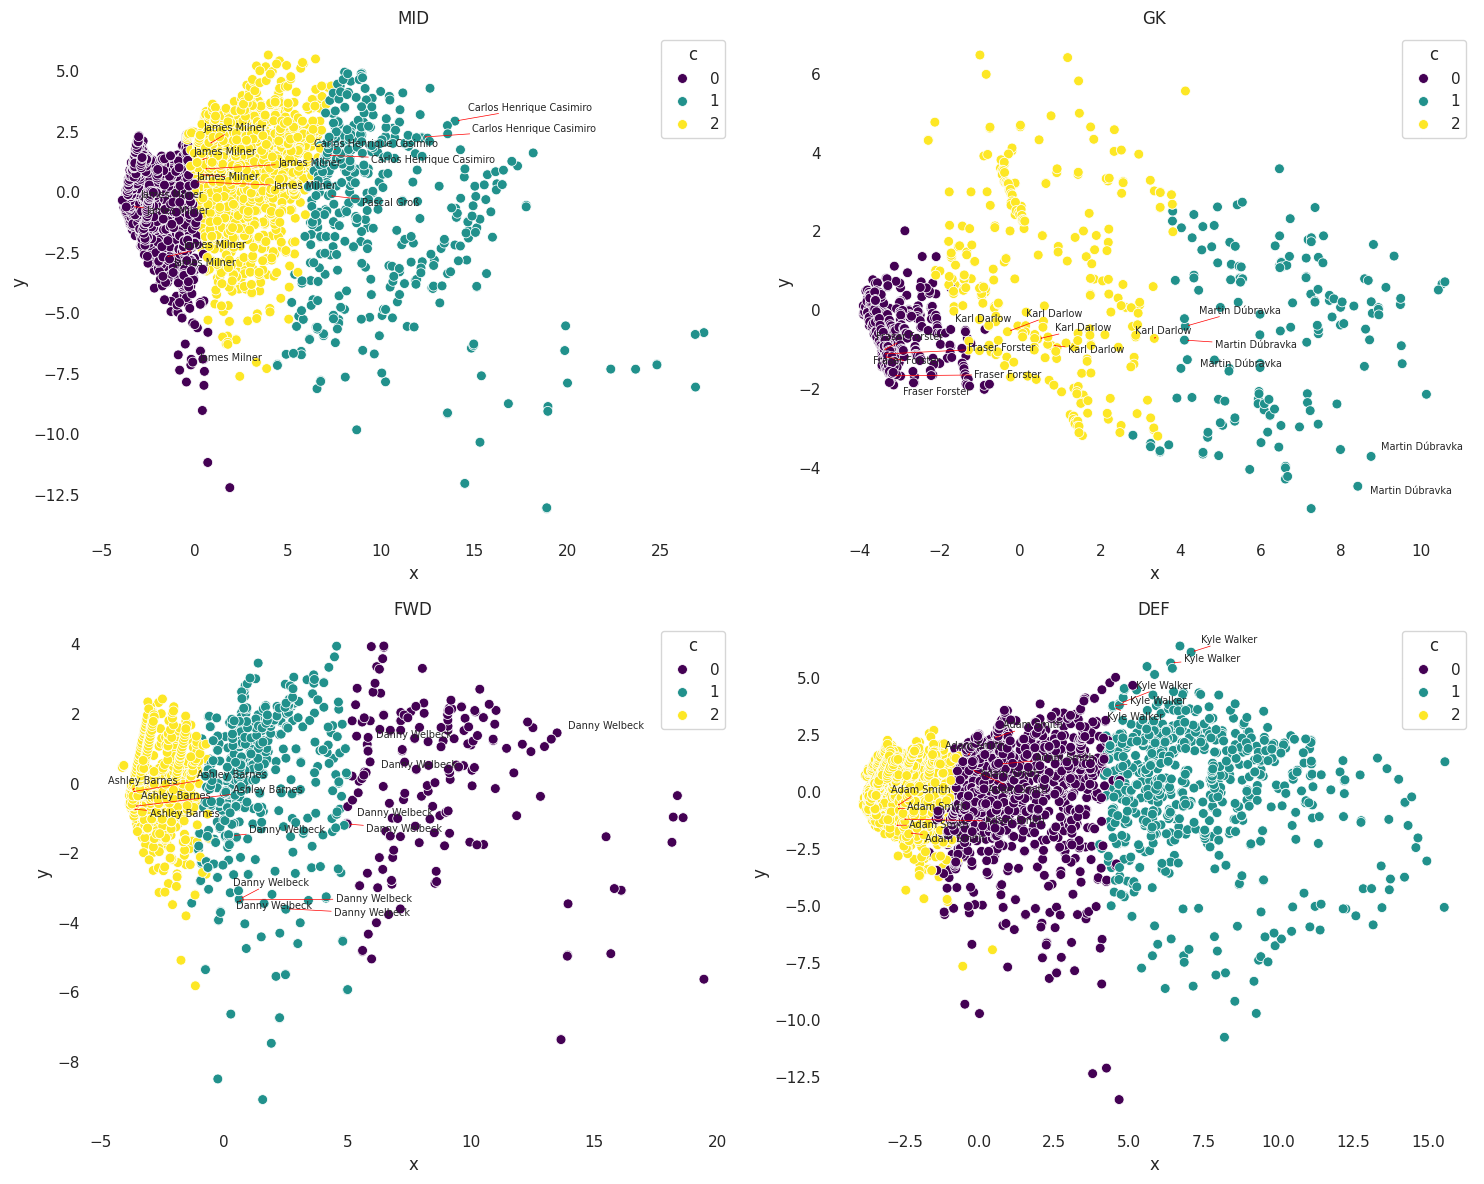

In [ ]:
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


df = data[data.season == data.season.max()]
f = df.select_dtypes('number').columns.drop(['id', 'season'], 'ignore')
fig, ax_list = plt.subplots(2, 2, figsize=(15, 12))

for ax, pos in zip(ax_list.flat, df.position.unique()):
    d = df[df.position == pos].copy()
    X = StandardScaler().fit_transform(d[f].fillna(0))
    d['c'] = KMeans(3, n_init=10, random_state=42).fit_predict(X)
    p = PCA(2).fit_transform(X)
    d['x'], d['y'] = p[:, 0], p[:, 1]

    sns.scatterplot(data=d, x='x', y='y', hue='c', ax=ax, palette='viridis', s=50)
    txt = [ax.text(r.x, r.y, r['name'], fontsize=7) for c in range(3) for _, r in d[d.c==c].head(5).iterrows()]
    adjust_text(txt, ax=ax, arrowprops=dict(arrowstyle='->', color='red', lw=0.5))
    
    print(f"\n{pos}:" + "".join([f"\nK{c}: {', '.join(d[d.c==c]['name'].head(8))}" for c in range(3)]))
    ax.set_title(pos)

plt.tight_layout()
plt.show()

In [46]:
"""data.to_parquet(config.TIDY_DATA_PATH)"""

'data.to_parquet(config.TIDY_DATA_PATH)'